In [41]:
# 여드름 40대 이상 봐주지 않는다.
# 이미지 사이즈 384 이상
# 주름 데이터 추가

In [1]:
import json
import os

paths_json = '/home/work/hocheol_dir/workspace/datasets2/age_data/v0.2/age_label_paths.json'
img_root = '/home/work/hocheol_dir/workspace/datasets2/age_data/v0.2/v0.2_data'

with open(paths_json, 'r') as f:
    paths = json.load(f)

wrinkle_data = []

# 주름 정보 로드
for path in paths:
    for step in ['train', 'val', 'test']:
        wrinkle_path = os.path.join(path, 'wrinkle_boxes', f"age_{step}.json")
        with open(wrinkle_path, 'r') as f:
            wrinkle_data.extend(json.load(f))

len(wrinkle_data)

183447

In [2]:
size_data = []
for path in paths:
    for step in ['train', 'val', 'test']:
        size_path = os.path.join(path, 'add_img_size', f"age_{step}.json")
        with open(size_path, 'r') as f:
            for data in json.load(f):
                if data['size']['height'] >= 384 and data['size']['width'] >= 384:
                    data['step'] = step
                    size_data.append(data)
len(size_data)

174664

In [3]:
# 여드름 2개 이상 있는 데이터 제거
# score같은거는 /home/work/hocheol_dir/workspace/AcneDetection/efficientdet/models/efficientdet-d0/250804_121147 여기
acne_data = []

for path in paths:
    for step in ['train', 'val', 'test']:
        acne_path = os.path.join(path, 'tfrecord', '250804_121147', f"age_{step}.json")
        data = []
        with open(acne_path, 'r') as f:
            tmp = json.load(f)
        for i in range(len(tmp['paths'])):
            valid_boxes = []
            for j in range(len(tmp['scores'][i])):
                if tmp['scores'][i][j] >= 0.12:
                    valid_boxes.append((tmp['scores'][i][j], tmp['pred_boxes'][i][j]))
                tmp['pred_boxes'][i][j]
                tmp['scores'][i][j]
            if len(valid_boxes) < 2:
                data.append({'path': tmp['paths'][i], 'boxes': valid_boxes})

        acne_data.extend(data)
len(acne_data)

182275

In [4]:
len(wrinkle_data), len(size_data), len(acne_data)

(183447, 174664, 182275)

In [5]:
import pandas as pd
# data는 각 row 들어간다.
pd.DataFrame(columns=['hihi', 'qq'], data=[[1,3], [4,5]])

,hihi,qq
0,1,3
1,4,5


In [6]:
import pandas as pd
# v0.2.3에 남길 데이터 정리해야함
# pandas로 inner join한 다음 path 기준 dict로 합치기
# wrinkle은 정제가 아니라 나중에 추가할거고 size랑 acne만 교집합 찾기
wrinkle_paths, size_paths, acne_paths = [], [], []

for data in wrinkle_data:
    wrinkle_paths.append(data['path'])
for data in size_data:
    size_paths.append((data['path'], data['step']))
for data in acne_data:
    acne_paths.append(data['path'])

wrinkle_df = pd.DataFrame(wrinkle_paths, columns=['path'])
size_df = pd.DataFrame(size_paths, columns=['path', 'step'])
acne_df = pd.DataFrame(acne_paths, columns=['path'])

merged_df = pd.merge(size_df, acne_df, on='path', how='inner')
s = set(merged_df['path'].tolist())

# s에 있는게 교집합
data_dict = {}
for data in size_data:
    if data['path'] in s:
        data_dict[data['path']] = data

for data in wrinkle_data:
    if data['path'] in s:
        if data['path'] in data_dict:
            if data['gender'] != data_dict[data['path']]['gender']:
                raise ValueError("Gender mismatch:", data['path'])
            if data['age'] != data_dict[data['path']]['age']:
                raise ValueError("Age mismatch:", data['path'])
            if data['age_class'] != data_dict[data['path']]['age_class']:
                raise ValueError("Age class mismatch:", data['path'])
            data_dict[data['path']]['sector_boxes'] = data['boxes']

len(wrinkle_df), len(size_df), len(acne_df), len(s), len(data_dict)

(183447, 174664, 182275, 173517, 173517)

In [7]:
final_data = []

for key, val in data_dict.items():
    final_data.append(val)

In [8]:
train_dict = {os.path.basename(os.path.dirname(path)): [] for path in paths}
val_dict = {os.path.basename(os.path.dirname(path)): [] for path in paths}
test_dict = {os.path.basename(os.path.dirname(path)): [] for path in paths}

lst = os.listdir('/home/work/hocheol_dir/workspace/datasets2/age_data/v0.2/v0.2.3')

for data in final_data:
    key = data['path'].split('/')[0]
    if key not in lst:
        print(key)
        break
    else:
        if data['step'] == 'train':
            train_dict[key].append({key: val for key, val in data.items() if key != 'step'})
        elif data['step'] == 'val':
            del data['step']
            val_dict[key].append({key: val for key, val in data.items() if key != 'step'})
        elif data['step'] == 'test':
            del data['step']
            test_dict[key].append({key: val for key, val in data.items() if key != 'step'})
        else:
            raise ValueError("Step mismatch:", data['step'])

In [9]:
print('train')
for key, val in train_dict.items():
    print('-', len(val))

print('\nval')
for key, val in val_dict.items():
    print('-', len(val))

print('\ntest')
for key, val in test_dict.items():
    print('-', len(val))

train
- 2245
- 1262
- 4199
- 2440
- 51983
- 9941
- 1917
- 15583
- 1534
- 47527

val
- 278
- 154
- 528
- 285
- 9962
- 1969
- 269
- 2053
- 190
- 5730

test
- 283
- 154
- 523
- 293
- 3039
- 490
- 260
- 2076
- 184
- 6166


In [11]:
root_dir = '/home/work/hocheol_dir/workspace/datasets2/age_data/v0.2/v0.2.3'

for key, val in train_dict.items():
    file_name = os.path.join(root_dir, key, 'label', 'age_train.json')
    os.makedirs(os.path.dirname(file_name), exist_ok=True)
    with open(file_name, 'w') as f:
        json.dump(val, f, indent=2, ensure_ascii=False)
    
for key, val in val_dict.items():
    file_name = os.path.join(root_dir, key, 'label', 'age_val.json')
    os.makedirs(os.path.dirname(file_name), exist_ok=True)
    with open(file_name, 'w') as f:
        json.dump(val, f, indent=2, ensure_ascii=False)
    
for key, val in test_dict.items():
    file_name = os.path.join(root_dir, key, 'label', 'age_test.json')
    os.makedirs(os.path.dirname(file_name), exist_ok=True)
    with open(file_name, 'w') as f:
        json.dump(val, f, indent=2, ensure_ascii=False)


### 박스 확인

In [114]:
# random.sample로 꺼내면서 박스 확인해보기
# 확인하고 이제 데이터로더에 augmentation 넣기

In [12]:
import json
import os

json_data = []

with open('/home/work/hocheol_dir/workspace/datasets2/age_data/v0.2/v0.2.3/age_label_paths.json', 'r') as f:
    paths = json.load(f)
for path in paths:
    for step in ['train', 'val', 'test']:
        json_path = os.path.join(path, f"age_{step}.json")
        with open(json_path, 'r') as f:
            json_data.extend(json.load(f))
len(json_data)

173517

In [24]:
import random
import matplotlib.pyplot as plt
from matplotlib import patches

image_root = '/home/work/hocheol_dir/workspace/datasets2/age_data/v0.2/v0.2_data'

data = random.sample(json_data, 1)[0]
data

{'user_id': '0555',
 'path': '114_data/data/0555_Tablet_Mid_017.jpg',
 'gender': 'male',
 'age': '40s',
 'age_class': 3,
 'size': {'height': 913, 'width': 806, 'channels': 3},
 'sector_boxes': {'forehead': {'y_min': 0,
   'x_min': 108,
   'y_max': 190,
   'x_max': 621},
  'right_eye': {'y_min': 230, 'x_min': 13, 'y_max': 447, 'x_max': 269},
  'left_eye': {'y_min': 222, 'x_min': 430, 'y_max': 462, 'x_max': 732},
  'nasolabial': {'y_min': 371, 'x_min': 119, 'y_max': 665, 'x_max': 595},
  'oral': {'y_min': 570, 'x_min': 119, 'y_max': 825, 'x_max': 611}}}

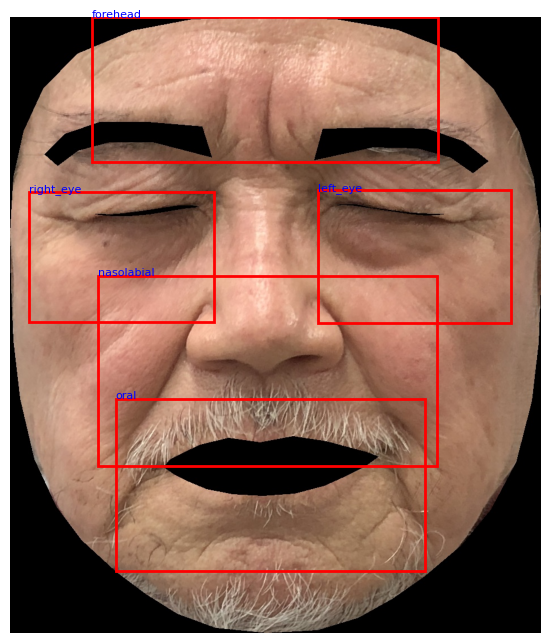

In [59]:
data = random.sample(json_data, 1)[0]
img_path = os.path.join(image_root, data['path'])

fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax.imshow(plt.imread(img_path))

for sector, box in data['sector_boxes'].items():
    x_min, y_min, x_max, y_max = box['x_min'], box['y_min'], box['x_max'], box['y_max']
    rect = patches.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    ax.text(x_min, y_min, sector, color='blue', fontsize=8)
ax.axis('off')

plt.show()

In [ ]:
# 114_data/data/1424_Tablet_Low_018.jpg 눈가 마스킹